# TidalSense Study — Exploratory Data Analysis

Walk-through of the two study tables before doing the operational analysis in `analysis.ipynb`. Goal: understand shape, data quality, and obvious patterns that motivate the findings later.

In [1]:
# ── Helper functions (kept inline so the notebook is self-contained) ──
import json
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Use the PNG renderer (via kaleido) so each chart is baked into the notebook
# output as an actual image. This means the figures render everywhere — locally
# in Jupyter, on GitHub, in nbviewer, in VS Code — without needing plotly.js to
# load. We also widen the default size for legibility.
pio.renderers.default = "png"
pio.kaleido.scope.default_width = 1100
pio.kaleido.scope.default_height = 480

# Resolve data folder whether the notebook is launched from repo root or notebooks/
_here = Path.cwd()
DATA_DIR = next(p for p in [_here / "data/raw", _here.parent / "data/raw"] if p.exists())

def load_software():
    df = pd.read_csv(DATA_DIR / "software_table.csv",
                     parse_dates=["test_log_time", "test_processed_time"])
    df["handset_num"] = df["handset_ID"].str.extract(r"(\d+)$").astype(int)
    df["processing_delay_s"] = (df["test_processed_time"] - df["test_log_time"]).dt.total_seconds()
    df["date"] = df["test_log_time"].dt.date
    df["dow"] = df["test_log_time"].dt.day_name()
    df["hour"] = df["test_log_time"].dt.hour
    df["is_weekend"] = df["test_log_time"].dt.weekday >= 5
    df["any_automated_error"] = (df["automated_check_hardware_error"]
                                 | df["automated_check_software_error"]
                                 | df["miscalibration"])
    return df

def load_hardware():
    return pd.read_csv(DATA_DIR / "hardware_telemetry_table.csv", parse_dates=["log_time"])

def _safe_loads(s):
    try:
        return json.loads(s) if isinstance(s, str) else {}
    except Exception:
        return {}

def parse_telemetry(hw):
    out = hw.copy()
    parsed = out["message"].apply(_safe_loads)
    out["status"] = parsed.apply(lambda d: d.get("status"))
    out["voltage"] = parsed.apply(lambda d: d.get("voltage"))
    out["signal_strength"] = parsed.apply(lambda d: d.get("signal_strength"))
    out["firmware_version"] = parsed.apply(lambda d: d.get("firmware_version"))
    return out

def attach_firmware(sw, hw_parsed):
    """For each test, attach the firmware version active on that handset at that time."""
    fw = (hw_parsed.loc[hw_parsed["component"] == "firmware",
                        ["ID", "log_time", "firmware_version"]]
          .dropna()
          .rename(columns={"ID": "handset_num", "log_time": "fw_time"})
          .sort_values(["handset_num", "fw_time"]))
    pieces = []
    for h, g in sw.sort_values(["handset_num", "test_log_time"]).groupby("handset_num", sort=False):
        fw_g = fw[fw["handset_num"] == h]
        if fw_g.empty:
            g = g.assign(firmware_at_test=pd.NA)
        else:
            g = pd.merge_asof(
                g, fw_g[["fw_time", "firmware_version"]]
                    .rename(columns={"fw_time": "test_log_time",
                                     "firmware_version": "firmware_at_test"}),
                on="test_log_time", direction="backward")
        pieces.append(g)
    return pd.concat(pieces, ignore_index=True).sort_values("test_log_time")

def handset_health(sw, hw_parsed):
    """Combined per-handset summary used by the analysis notebook."""
    sw_g = sw.groupby("handset_num").agg(
        practice=("practice_ID","first"),
        tests=("test_log_time","count"),
        miscal=("miscalibration","sum"),
        hw_err=("automated_check_hardware_error","sum"),
        sw_err=("automated_check_software_error","sum"),
        timeouts=("user_error", lambda s: (s=="Timeout").sum()),
        last_test=("test_log_time","max"),
    )
    for col, base in [("miscal_rate","miscal"),("hw_err_rate","hw_err"),
                      ("sw_err_rate","sw_err"),("timeout_rate","timeouts")]:
        sw_g[col] = sw_g[base] / sw_g["tests"]
    batt = (hw_parsed.query("component == 'battery'")
            .groupby("ID")["voltage"].agg(batt_mean="mean", batt_min="min"))
    sig = (hw_parsed.query("component == 'modem'")
           .groupby("ID")["signal_strength"].agg(signal_mean="mean", signal_min="min"))
    crit_b = (hw_parsed.query("component == 'battery' and status == 'CRITICAL'")
              .groupby("ID").size().rename("battery_critical_events"))
    crit_m = (hw_parsed.query("component == 'modem' and status == 'CRITICAL'")
              .groupby("ID").size().rename("modem_critical_events"))
    fw_evt = (hw_parsed.query("component == 'firmware'")
              .groupby("ID").agg(firmware_events=("firmware_version","count"),
                                 last_firmware=("firmware_version","last"),
                                 last_telemetry=("log_time","max")))
    tel = hw_parsed.groupby("ID").size().rename("telemetry_events")
    out = (sw_g.join(batt).join(sig).join(crit_b).join(crit_m).join(fw_evt).join(tel))
    out["battery_critical_events"] = out["battery_critical_events"].fillna(0).astype(int)
    out["modem_critical_events"]   = out["modem_critical_events"].fillna(0).astype(int)
    out["silence_days"] = (out["last_test"] - out["last_telemetry"]).dt.days
    return out


In [2]:
sw = load_software()
hw = load_hardware()
hw_parsed = parse_telemetry(hw)
print('Software table :', sw.shape)
print('Hardware table :', hw.shape)
sw.head(3)

Software table : (8678, 18)
Hardware table : (3426, 5)


,test_log_time,test_processed_time,practice_ID,administrator_ID,handset_ID,boot_ID,automated_check_hardware_error,automated_check_software_error,user_error,miscalibration,diagnosis,handset_num,processing_delay_s,date,dow,hour,is_weekend,any_automated_error
0,2026-04-07 08:03:37,2026-04-07 08:03:37.225410,PRC-009,ADM-021,handset-00018,2,False,False,no_error,False,negative,18,0.22541,2026-04-07,Tuesday,8,False,False
1,2026-04-07 08:04:16,2026-04-07 08:04:16.106370,PRC-001,ADM-001,handset-00001,2,False,False,no_error,False,negative,1,0.10637,2026-04-07,Tuesday,8,False,False
2,2026-04-07 08:05:48,2026-04-07 08:05:48.759000,PRC-003,ADM-006,handset-00005,2,False,False,no_error,False,negative,5,0.75900,2026-04-07,Tuesday,8,False,False


## 1. Schema and missing values

In [3]:
missing = pd.DataFrame({
    'software':  sw.isna().sum(),
    'hardware':  hw_parsed.isna().sum(),
})
missing[missing.sum(axis=1) > 0]

,software,hardware
component,NaN,102.0
firmware_version,NaN,3030.0
message,NaN,8.0
signal_strength,NaN,1830.0
status,NaN,416.0
voltage,NaN,2012.0


Software table is fully populated. Hardware table has 102 rows with a missing `component` and 8 with no `message` payload — flagged as a minor data-quality issue.

## 2. Study window and daily volume

In [4]:
print('Window:', sw.test_log_time.min().date(), '→', sw.test_log_time.max().date())
print('Days  :', sw['date'].nunique())
print('Tests :', len(sw))

Window: 2026-04-07 → 2026-05-06
Days  : 30
Tests : 8678


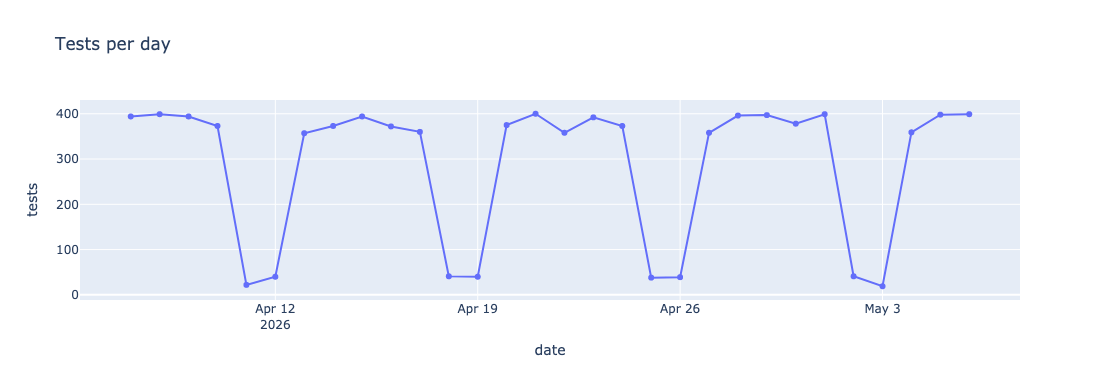

In [5]:
daily = sw.groupby('date').size().reset_index(name='tests')
daily['date'] = pd.to_datetime(daily['date'])
fig = px.line(daily, x='date', y='tests', markers=True, title='Tests per day')
fig.update_layout(height=380)
fig.show()

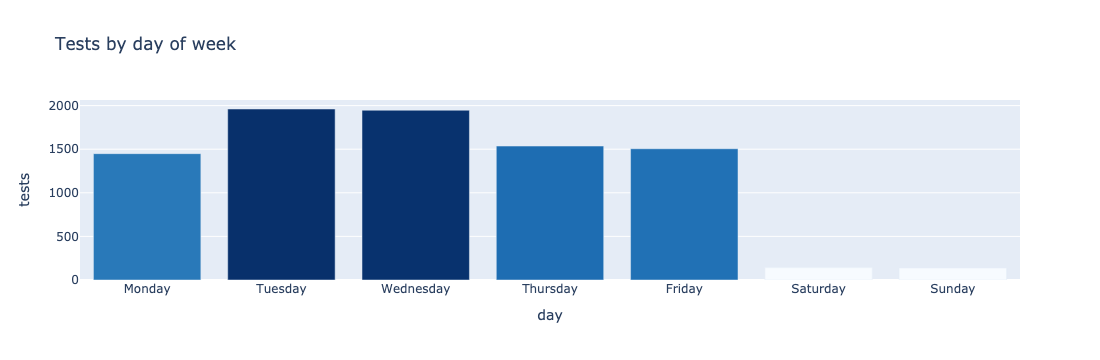

In [6]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = sw['dow'].value_counts().reindex(dow_order).reset_index()
dow.columns = ['day','tests']
fig = px.bar(dow, x='day', y='tests', title='Tests by day of week',
             color='tests', color_continuous_scale='Blues')
fig.update_layout(height=360, coloraxis_showscale=False)
fig.show()

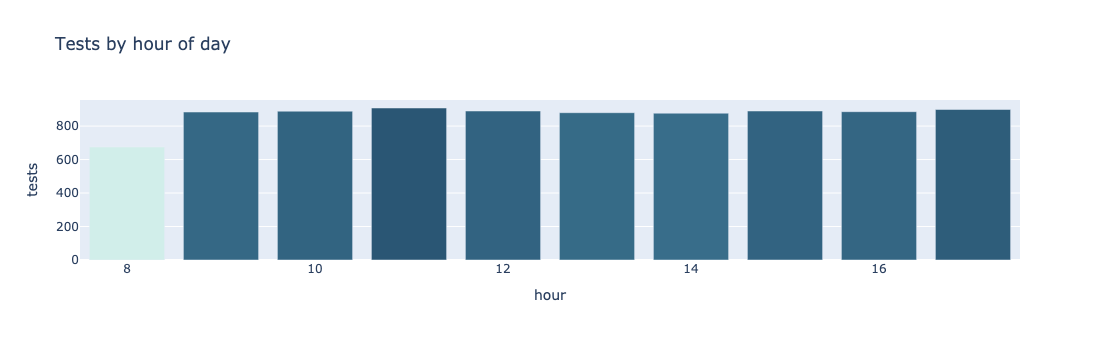

In [7]:
hour = sw.groupby('hour').size().reset_index(name='tests')
fig = px.bar(hour, x='hour', y='tests', title='Tests by hour of day',
             color='tests', color_continuous_scale='Teal')
fig.update_layout(height=340, coloraxis_showscale=False)
fig.show()

All tests run between 08:00 and 17:59. Mid-week is busier than early/late week. Weekend tests exist but are an order of magnitude smaller — important because TidalSense provides no weekend support.

## 3. Outcomes and error flags

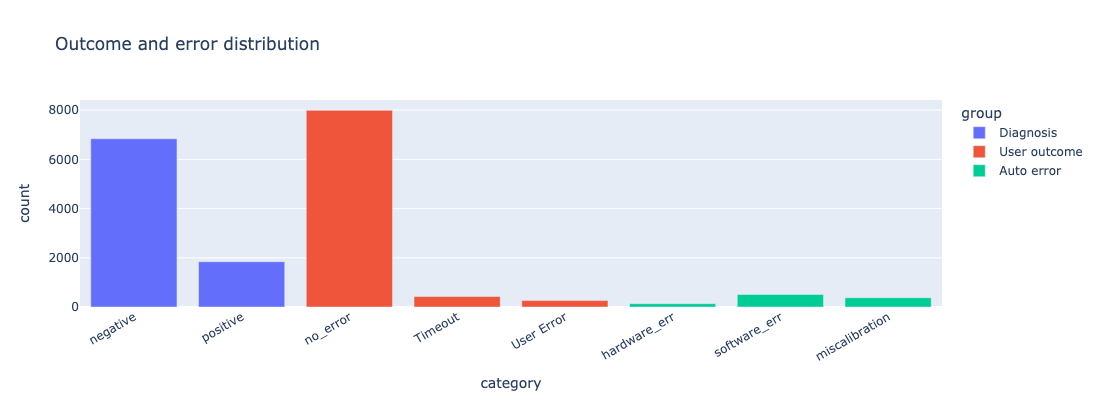

In [8]:
counts = pd.DataFrame({
    'category': ['negative','positive','no_error','Timeout','User Error',
                 'hardware_err','software_err','miscalibration'],
    'count': [
        (sw.diagnosis=='negative').sum(),
        (sw.diagnosis=='positive').sum(),
        (sw.user_error=='no_error').sum(),
        (sw.user_error=='Timeout').sum(),
        (sw.user_error=='User Error').sum(),
        sw.automated_check_hardware_error.sum(),
        sw.automated_check_software_error.sum(),
        sw.miscalibration.sum(),
    ],
    'group': ['Diagnosis']*2 + ['User outcome']*3 + ['Auto error']*3
})
fig = px.bar(counts, x='category', y='count', color='group',
             title='Outcome and error distribution')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

## 4. Practice and handset coverage

In [9]:
coverage = sw.groupby('practice_ID').agg(
    handsets=('handset_ID','nunique'),
    admins=('administrator_ID','nunique'),
    tests=('test_log_time','count'),
)
coverage

,handsets,admins,tests
practice_ID,,,
PRC-001,2,2,857
PRC-002,2,3,835
PRC-003,2,3,850
PRC-004,2,2,825
PRC-005,2,2,850
PRC-006,2,2,849
PRC-007,2,3,804
PRC-008,2,3,854
PRC-009,2,2,1116


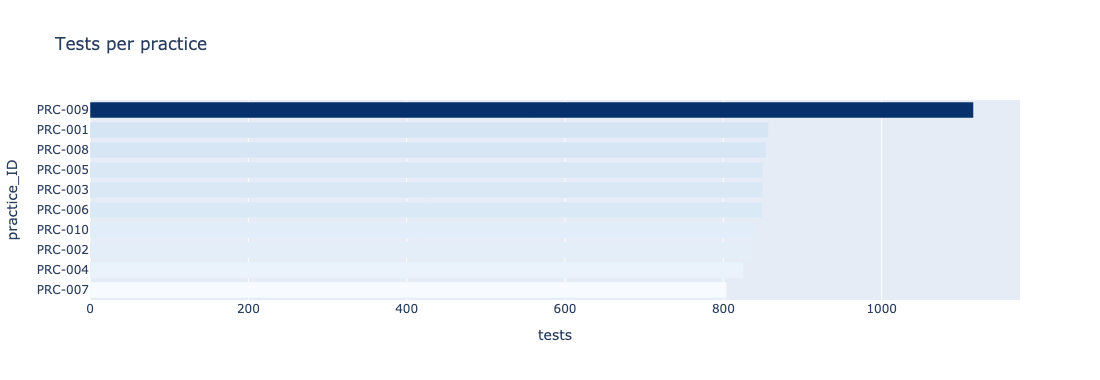

In [10]:
vol = sw.groupby('practice_ID').size().reset_index(name='tests').sort_values('tests')
fig = px.bar(vol, x='tests', y='practice_ID', orientation='h',
             title='Tests per practice', color='tests',
             color_continuous_scale='Blues')
fig.update_layout(height=380, coloraxis_showscale=False)
fig.show()

PRC-009 stands out at ~33% above the median — flagged in the analysis.

## 5. Per-handset error ranking

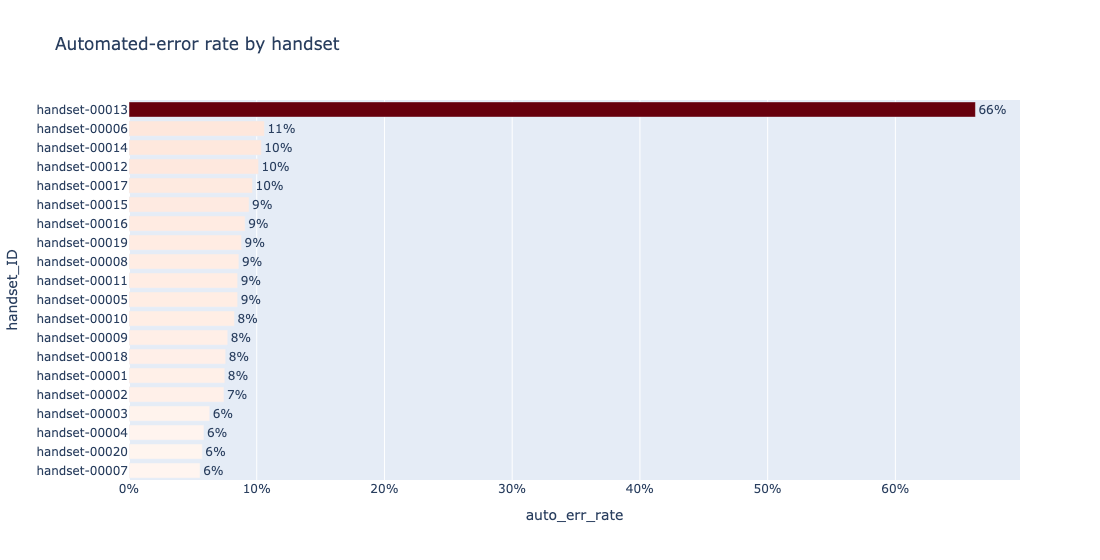

In [11]:
hh = sw.groupby(['handset_ID','practice_ID']).agg(
    tests=('test_log_time','count'),
    auto_err_rate=('any_automated_error','mean'),
    miscal_rate=('miscalibration','mean'),
).reset_index().sort_values('auto_err_rate', ascending=True)
fig = px.bar(hh, y='handset_ID', x='auto_err_rate', orientation='h',
             color='auto_err_rate', color_continuous_scale='Reds',
             title='Automated-error rate by handset',
             text=hh['auto_err_rate'].apply(lambda v: f'{v:.0%}'))
fig.update_layout(height=560, xaxis_tickformat='.0%', coloraxis_showscale=False)
fig.update_traces(textposition='outside')
fig.show()

One handset (00013) is a clear outlier — explored in the analysis.

## 6. Telemetry: battery, modem, firmware

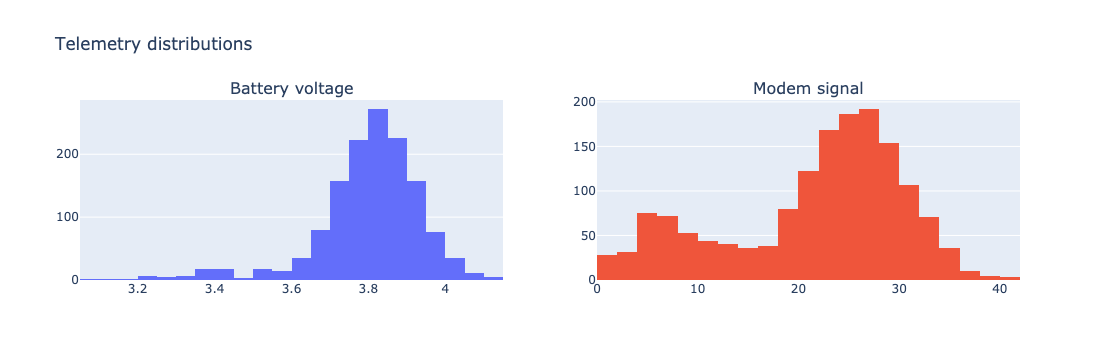

In [12]:
batt = hw_parsed.query("component == 'battery'")
mod  = hw_parsed.query("component == 'modem'")
fw   = hw_parsed.query("component == 'firmware'")

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Battery voltage', 'Modem signal'))
fig.add_trace(go.Histogram(x=batt['voltage'], nbinsx=40, name='battery'), row=1, col=1)
fig.add_trace(go.Histogram(x=mod['signal_strength'], nbinsx=40, name='modem'), row=1, col=2)
fig.update_layout(height=360, showlegend=False, title_text='Telemetry distributions')
fig.show()

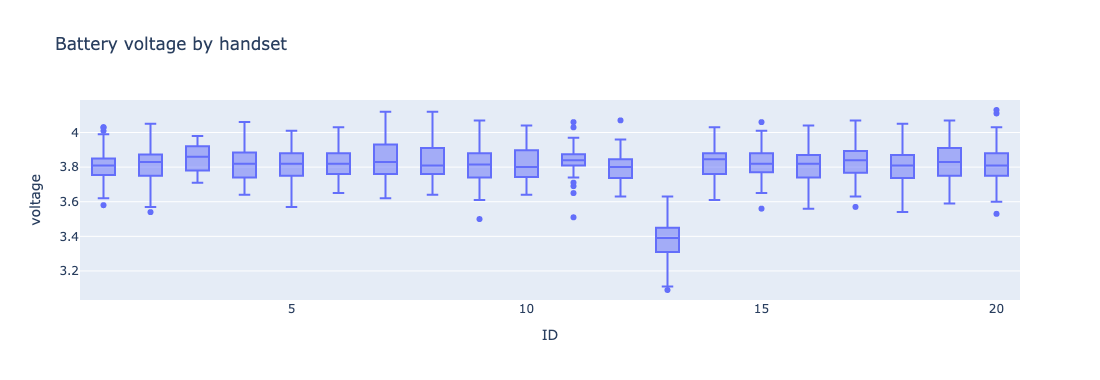

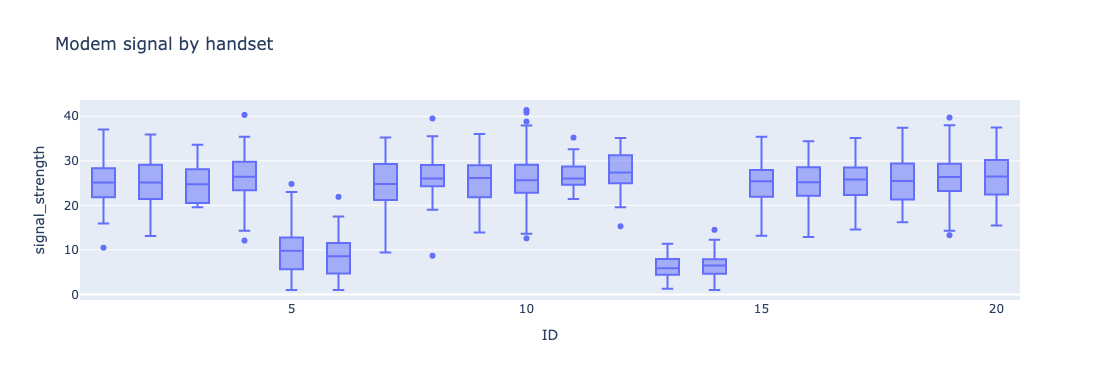

In [13]:
fig = px.box(batt, x='ID', y='voltage', title='Battery voltage by handset')
fig.update_layout(height=380)
fig.show()

fig = px.box(mod, x='ID', y='signal_strength', title='Modem signal by handset')
fig.update_layout(height=380)
fig.show()

Two patterns visible: (1) one handset has a clearly depressed battery voltage distribution; (2) several handsets sit far below the rest of the fleet on modem signal.

## 7. Firmware rollout timeline

In [14]:
fw_first = fw.groupby('firmware_version')['log_time'].min().sort_values().reset_index()
fw_first.columns = ['firmware', 'first_seen']
fw_first

,firmware,first_seen
0,1.0.0,2026-04-07 08:03:37
1,1.1.2,2026-04-13 08:02:10
2,1.2.0,2026-04-18 08:14:25
3,2.0.1,2026-04-28 08:02:41


In [15]:
fw_per_handset = (fw.groupby(['ID','firmware_version'])['log_time'].min()
                    .unstack().reset_index())
fw_per_handset

firmware_version,ID,1.0.0,1.1.2,1.2.0,2.0.1
0,1,2026-04-07 08:04:16,2026-04-14 08:56:26,2026-04-20 08:15:13,2026-04-28 08:32:14
1,2,2026-04-07 08:56:28,2026-04-13 08:45:44,2026-04-21 08:48:13,2026-04-28 08:13:30
2,3,2026-04-07 08:11:26,NaT,NaT,NaT
3,4,2026-04-07 08:45:32,2026-04-15 08:23:40,2026-04-20 08:33:07,2026-04-28 08:02:41
4,5,2026-04-07 08:05:48,2026-04-13 08:30:06,2026-04-20 08:35:46,2026-04-28 08:13:27
5,6,2026-04-07 08:34:02,2026-04-13 08:10:58,2026-04-20 08:31:20,2026-04-28 08:20:30
6,7,2026-04-07 08:48:06,2026-04-13 08:35:49,2026-04-20 08:21:59,2026-04-28 08:34:47
7,8,2026-04-07 08:28:51,2026-04-13 08:08:19,2026-04-20 08:36:30,2026-04-28 08:08:02
8,9,2026-04-07 08:35:51,2026-04-13 08:39:55,2026-04-20 08:19:00,2026-04-28 08:36:48
9,10,2026-04-07 08:11:17,2026-04-13 08:35:48,2026-04-20 08:33:03,2026-04-28 08:17:41


Four firmware versions rolled out across the study, in roughly weekly waves. Several handsets never reached the latest version — investigated in the analysis.

## 8. Boot frequency per handset

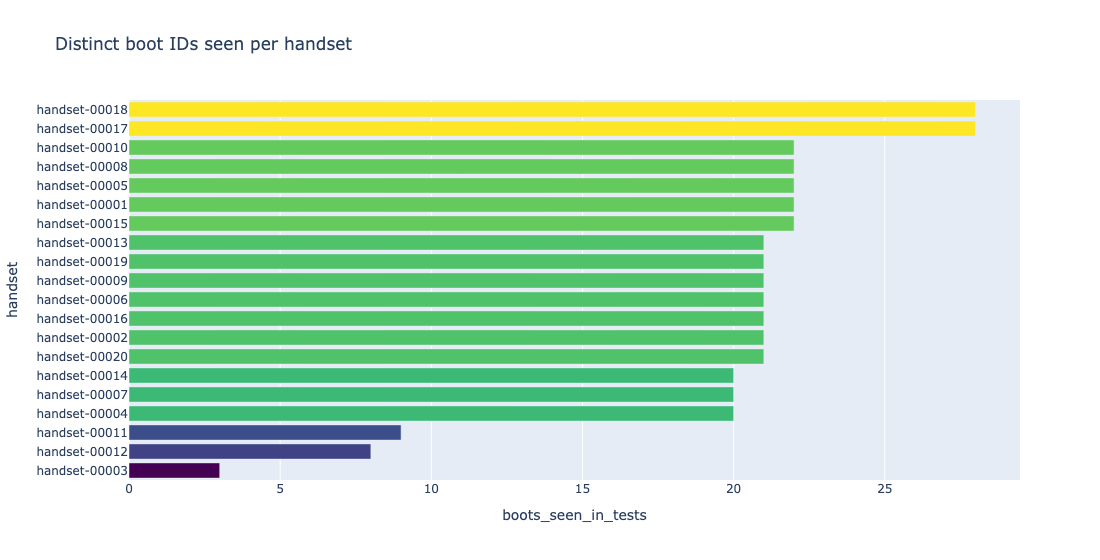

In [16]:
boots = sw.groupby('handset_num')['boot_ID'].nunique().reset_index(name='boots_seen_in_tests')
boots['handset'] = 'handset-' + boots['handset_num'].astype(str).str.zfill(5)
fig = px.bar(boots.sort_values('boots_seen_in_tests'), x='boots_seen_in_tests',
             y='handset', orientation='h', title='Distinct boot IDs seen per handset',
             color='boots_seen_in_tests', color_continuous_scale='Viridis')
fig.update_layout(height=560, coloraxis_showscale=False)
fig.show()

Most handsets reboot daily (~21 boots over 30 days). A few have far fewer — either being booted less often or failing to register boots. Worth a look.

## 9. Numeric correlation

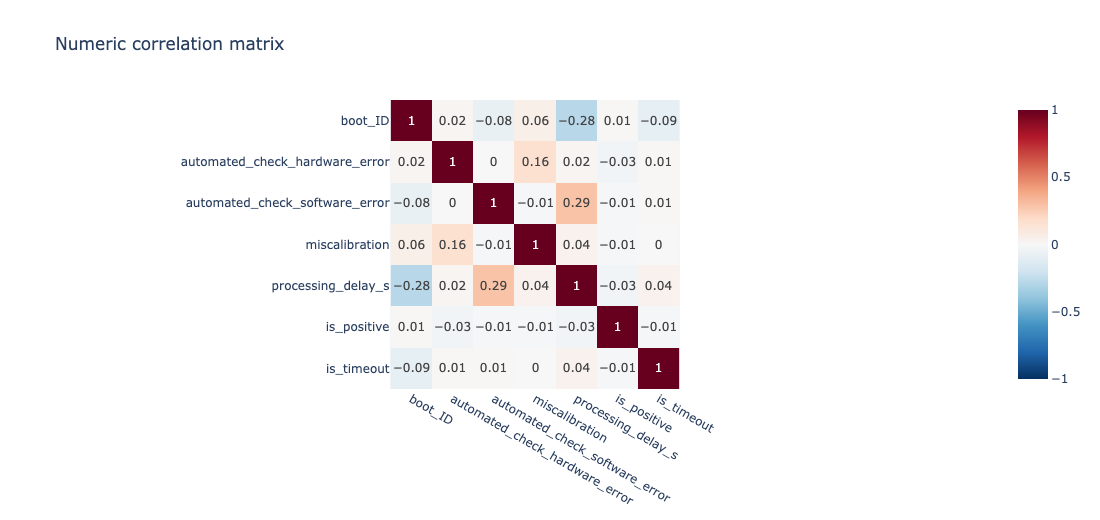

In [17]:
num = sw[['boot_ID','automated_check_hardware_error',
         'automated_check_software_error','miscalibration',
         'processing_delay_s']].astype(float)
num['is_positive'] = sw['diagnosis'].eq('positive').astype(float)
num['is_timeout']  = sw['user_error'].eq('Timeout').astype(float)
corr = num.corr().round(2)
fig = px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1, title='Numeric correlation matrix')
fig.update_layout(height=520)
fig.show()

Correlations are mostly weak — error events are rare, and the real signal lives in groupings (handset / practice / firmware) rather than in pairwise numeric relationships. The analysis notebook leans on those groupings explicitly.

## 10. Takeaways for the analysis notebook

1. Data quality is high overall; only the hardware-table `component` column has notable missingness (~3%).
2. One handset's battery voltage and miscalibration rate are obvious outliers.
3. Modem signal varies dramatically by site — a likely fault source.
4. Firmware rolled out in waves, so per-version error rates matter.
5. Per-practice positivity differs by ~5×; needs framing.
6. Some handsets are booting far less frequently than peers.
7. Some weekend testing falls outside support coverage.